# Vocabulario Óptimo: max_features y min_df con Character N-Grams + LinearSVC

Este notebook profundiza en los hallazgos de la iteración 7 (Kaggle 0.30085) explorando de forma sistemática la combinación de **tamaño de vocabulario** (`max_features`) y **frecuencia mínima de documento** (`min_df`) mediante `GridSearchCV` con validación cruzada estratificada.

Se utilizan dos rejillas de hiperparámetros separadas para respetar las restricciones de memoria:
- **Rejilla A — `min_df=1`**: incluye n-grams que aparecen una sola vez; requiere vocabularios más pequeños (≤ 200 k) para no desbordar la RAM.
- **Rejilla B — `min_df=2`**: filtra hápax legómena; permite vocabularios más grandes (≤ 350 k).

El clasificador es `LinearSVC`, el de mayor rendimiento para TF-IDF de alta dimensionalidad. El pipeline garantiza que la transformación TF-IDF se ajuste únicamente sobre los datos de entrenamiento de cada fold.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 2. Carga de los datos

Cargamos el conjunto de entrenamiento y el de evaluación de forma independiente.

In [2]:
df = pd.read_csv('train.csv')
df_eval = pd.read_csv('eval.csv')

df['text']      = df['text'].fillna('')
df_eval['text'] = df_eval['text'].fillna('')

In [3]:
df.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


In [4]:
df.shape

(31403, 2)

## 3. Exploración del conjunto de datos

Revisamos la distribución de la variable objetivo y la calidad general del conjunto.

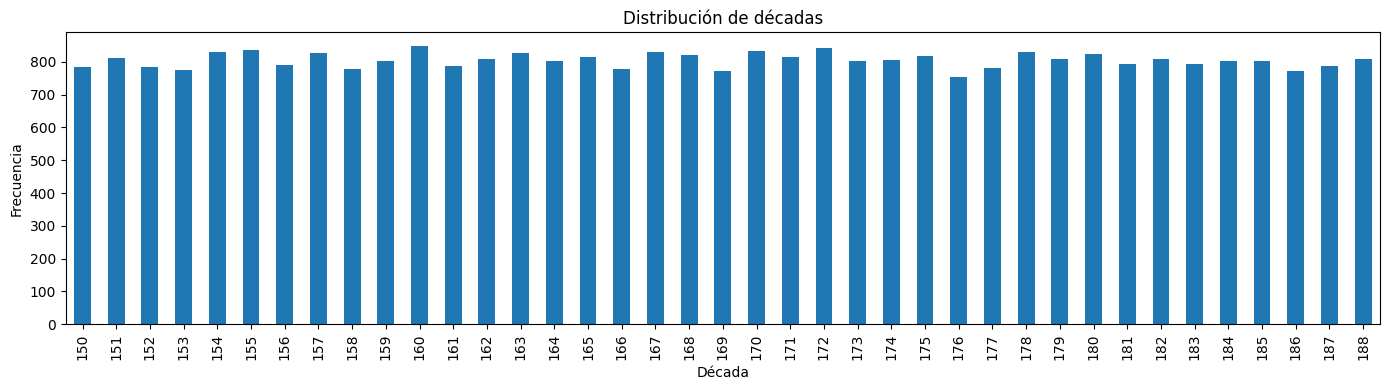

In [5]:
df['decade'].value_counts().sort_index().plot(
    kind='bar', figsize=(14, 4), title='Distribución de décadas'
)
plt.xlabel('Década')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [6]:
def reporte_calidad(df):
    reporte_de_cualidad = {
        'Total records': len(df),
        'duplicated record': df.duplicated().sum(),
        'missing values': df.isnull().sum().to_dict(),
        'data types': df.dtypes.astype(str).to_dict(),
    }
    return reporte_de_cualidad

print(reporte_calidad(df))

{'Total records': 31403, 'duplicated record': np.int64(34), 'missing values': {'text': 0, 'decade': 0}, 'data types': {'text': 'str', 'decade': 'int64'}}


## 4. Preprocesamiento del texto

Para textos históricos en español (siglos XVI–XIX) la ortografía **es** la señal temporal: la ñ, las tildes y las grafías arcaicas evolucionaron de forma diferente en cada época. Por eso desactivamos explícitamente `strip_accents=None` dentro del vectorizador y evitamos cualquier normalización que destruya esa información.

La única limpieza que realizamos es eliminar duplicados exactos.

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print('Registros tras eliminar duplicados:', len(df))
df[['text', 'decade']].head()

Registros tras eliminar duplicados: 31369


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


## 5. Partición de los datos

In [8]:
X = df['text']
y = df['decade']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

Se usa `stratify=y` para mantener la proporción de clases en ambas particiones.

In [9]:
X_train.shape, X_val.shape

((25095,), (6274,))

## 6. Construcción del pipeline

El pipeline encadena el vectorizador TF-IDF de caracteres con `LinearSVC`. Los hiperparámetros base se fijan en los valores óptimos ya validados en las iteraciones anteriores:
- `analyzer='char'`: captura morfología y ortografía directamente.
- `ngram_range=(1, 7)`: desde caracteres individuales hasta heptagramas.
- `strip_accents=None`: preserva toda la información diacrítica.
- `sublinear_tf=True`: escala logarítmica para reducir el peso de n-grams muy frecuentes.
- `dtype=np.float32`: reduce el uso de memoria a la mitad respecto a float64.

Los hiperparámetros `max_features`, `min_df` y el parámetro de regularización `C` se exploran mediante `GridSearchCV`.

In [10]:
pipeline_vocab = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        strip_accents=None,
        analyzer='char',
        ngram_range=(1, 7),
        sublinear_tf=True,
        dtype=np.float32,
    )),
    ('clf', LinearSVC()),
])

## 7. Búsqueda de hiperparámetros

Se utilizan **dos rejillas separadas** para evitar el desbordamiento de memoria que ocurre cuando `min_df=1` se combina con vocabularios grandes (≥ 300 k features):

| Rejilla | `min_df` | `max_features` | Motivo |
|---------|----------|----------------|--------|
| A | 1 | 150 k, 200 k | `min_df=1` produce vocabularios explosivos; se limita el tamaño |
| B | 2 | 250 k, 300 k, 350 k | `min_df=2` filtra hápax; permite vocabularios más grandes |

Ambas rejillas comparten el mismo rango de `C` = [0.25, 0.35, 0.40, 0.50].

In [11]:
param_grid_mindf1 = {
    'tfidf__min_df':      [1],
    'tfidf__max_features': [150000, 200000],
    'clf__C':              [0.25, 0.35, 0.40, 0.50],
}

param_grid_mindf2 = {
    'tfidf__min_df':      [2],
    'tfidf__max_features': [250000, 300000, 350000],
    'clf__C':              [0.25, 0.35, 0.40, 0.50],
}

param_grid = [param_grid_mindf1, param_grid_mindf2]

In [12]:
kfold = KFold(n_splits=3, shuffle=True, random_state=0)
grid_vocab = GridSearchCV(
    pipeline_vocab, param_grid, cv=kfold,
    scoring='accuracy', n_jobs=-1, verbose=2
)

In [13]:
grid_vocab.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\jeron\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
51 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\jeron\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\jeron\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jeron\AppData

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...LinearSVC())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf__C': [0.25, 0.35, ...], 'tfidf__max_features': [150000, 200000], 'tfidf__min_df': [1]}, {'clf__C': [0.25, 0.35, ...], 'tfidf__max_features': [250000, 300000, ...], 'tfidf__min_df': [2]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intCont

In [14]:
print('Mejores hiperparámetros:', grid_vocab.best_params_)
print('Mejor score CV (accuracy):', round(grid_vocab.best_score_, 4))

Mejores hiperparámetros: {'clf__C': 0.25, 'tfidf__max_features': 200000, 'tfidf__min_df': 1}
Mejor score CV (accuracy): 0.2572


In [15]:
resultados_cv = pd.DataFrame(grid_vocab.cv_results_)
cols = ['param_clf__C', 'param_tfidf__min_df', 'param_tfidf__max_features',
        'mean_test_score', 'std_test_score', 'rank_test_score']
print(resultados_cv[cols].sort_values('rank_test_score').to_string(index=False))

 param_clf__C  param_tfidf__min_df  param_tfidf__max_features  mean_test_score  std_test_score  rank_test_score
         0.25                    1                     200000         0.257183        0.002196                1
         0.25                    1                     150000              NaN             NaN                2
         0.35                    1                     150000              NaN             NaN                2
         0.35                    1                     200000              NaN             NaN                2
         0.40                    1                     150000              NaN             NaN                2
         0.40                    1                     200000              NaN             NaN                2
         0.50                    1                     150000              NaN             NaN                2
         0.50                    1                     200000              NaN             NaN          

## 8. Evaluación del mejor modelo

Aplicamos el mejor pipeline encontrado por `GridSearchCV` sobre el conjunto de validación.

In [16]:
best_model = grid_vocab.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_val   = best_model.predict(X_val)

#### Comparación de rendimientos sobre entrenamiento y validación

In [17]:
print('Accuracy en entrenamiento:', round(accuracy_score(y_train, y_pred_train), 4))
print('Accuracy en validación:   ', round(accuracy_score(y_val,   y_pred_val),   4))
print('Mejor score CV (accuracy):', round(grid_vocab.best_score_,                4))

Accuracy en entrenamiento: 0.9964
Accuracy en validación:    0.2718
Mejor score CV (accuracy): 0.2572


In [18]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

         150       0.61      0.83      0.70       157
         151       0.49      0.73      0.58       161
         152       0.55      0.64      0.59       157
         153       0.52      0.68      0.59       154
         154       0.46      0.57      0.51       166
         155       0.34      0.29      0.31       167
         156       0.45      0.51      0.48       158
         157       0.31      0.28      0.29       165
         158       0.27      0.32      0.30       155
         159       0.21      0.29      0.24       160
         160       0.15      0.12      0.13       170
         161       0.15      0.10      0.12       157
         162       0.27      0.23      0.25       162
         163       0.17      0.15      0.16       165
         164       0.19      0.19      0.19       161
         165       0.15      0.13      0.14       163
         166       0.14      0.08      0.10       156
         167       0.24    

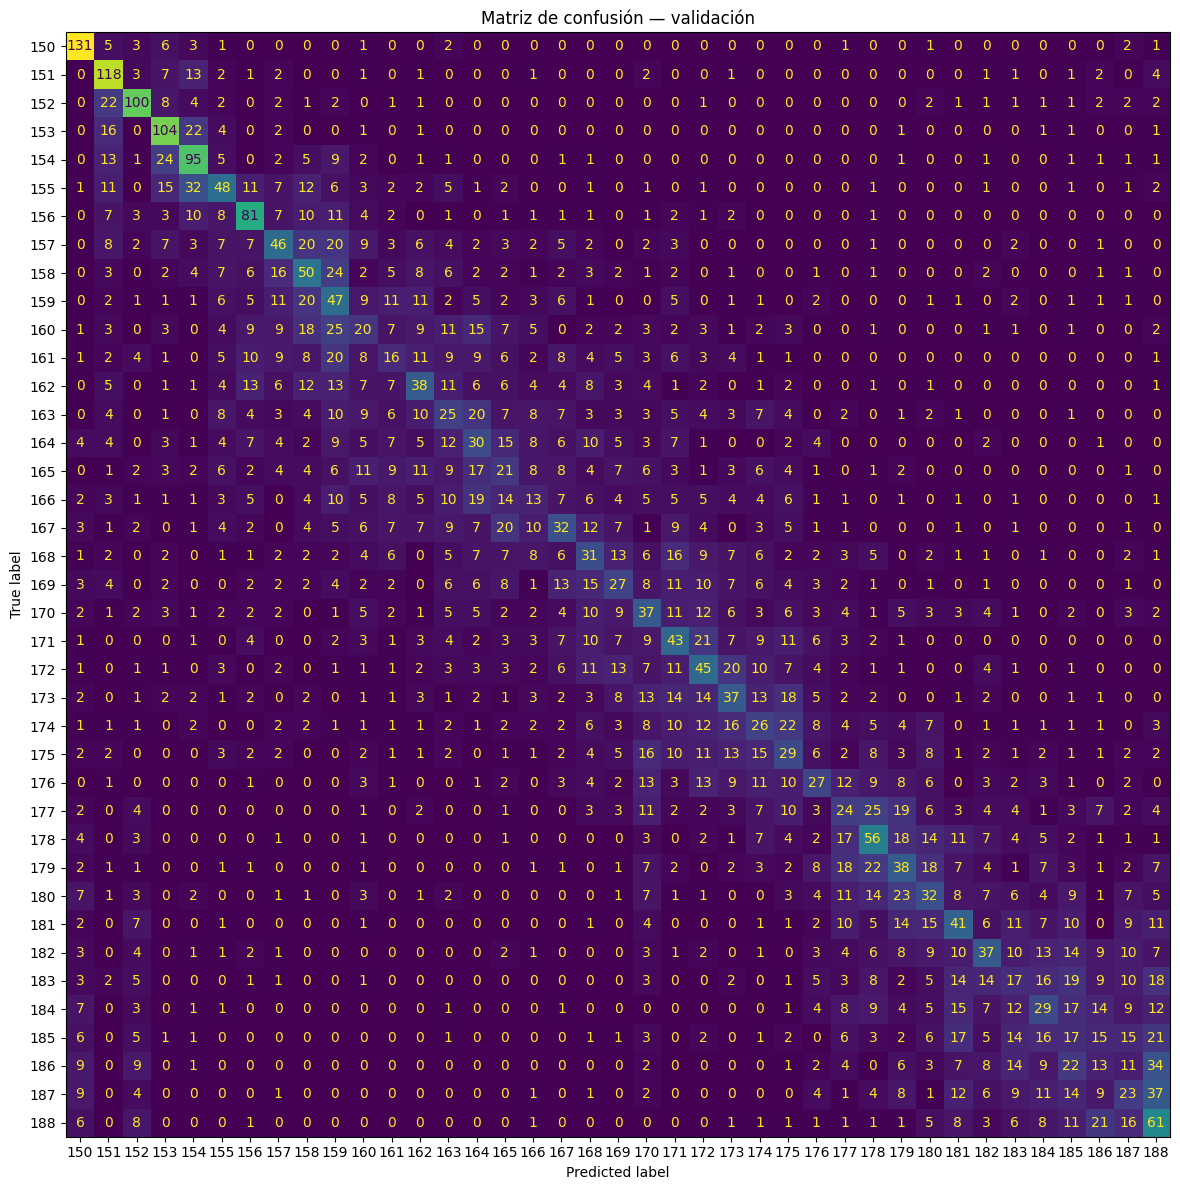

In [19]:
fig, ax = plt.subplots(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=ax, colorbar=False)
plt.title('Matriz de confusión — validación')
plt.tight_layout()
plt.show()

## 9. Predicciones sobre eval.csv

Reentrenamos el mejor pipeline sobre el conjunto de entrenamiento completo antes de generar las predicciones finales. Esto aprovecha todos los datos disponibles y produce un modelo más robusto que el evaluado en el paso anterior.

In [20]:
from sklearn.base import clone

final_model = clone(best_model)
final_model.fit(X, y)

print('Modelo reentrenado sobre el conjunto completo.')

Modelo reentrenado sobre el conjunto completo.


In [21]:
y_eval_pred = final_model.predict(df_eval['text']).astype(int)

submission = pd.DataFrame({'id': df_eval['id'], 'answer': y_eval_pred})
submission.to_csv('submission_vocab_opt.csv', index=False)

print('Filas generadas:', len(submission))
submission.head()

Filas generadas: 3490


,id,answer
0,0,173
1,1,186
2,2,150
3,3,169
4,4,153
